In [1]:
!pip install xgboost shap

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import files
uploaded = files.upload()

Saving materials_ml.parquet to materials_ml.parquet


In [5]:
import pandas as pd

df = pd.read_parquet("materials_ml.parquet")

print(df.shape)
df.head()

(20001, 14)


,material_id,band_gap,energy,cohesive_energy,space_group,Z_mean,Z_max,Z_var,SOC_proxy,EN_range,num_elements,magmom,is_metal,is_magnetic
0,matpes-20240214_999485_2,0.0,-16.832872,-2.481338,1,18.5,30,132.25,406200.5,1.39,2,0.001,True,False
1,matpes-20240214_999484_70,0.0,-31.680919,-3.805109,1,30.5,39,72.25,1273848.5,0.32,2,1.700,True,True
2,matpes-20240214_999484_47,0.0,-32.384422,-4.156860,8,30.5,39,72.25,1273848.5,0.32,2,1.829,True,True
3,matpes-20240214_999484_26,0.0,-31.967042,-3.948170,1,30.5,39,72.25,1273848.5,0.32,2,-2.059,True,False
4,matpes-20240214_999484_13,0.0,-31.691182,-3.810240,1,30.5,39,72.25,1273848.5,0.32,2,2.245,True,True


In [6]:
df["is_metal"].value_counts(normalize=True)

,proportion
is_metal,
True,0.913654
False,0.086346


In [10]:
# ----------------------------
# Define features and target
# ----------------------------
features = [
    "Z_mean",
    "Z_max",
    "Z_var",
    "SOC_proxy",
    "EN_range",
    "num_elements",
    "magmom"
]

X = df[features]
y = (~df["is_metal"]).astype(int)   # <-- THIS was missing before

# ----------------------------
# Train-test split
# ----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# Compute class weight
# ----------------------------
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 10.560693641618498


In [11]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.07,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.07, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [12]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3658
           1       0.55      0.84      0.66       343

    accuracy                           0.93      4001
   macro avg       0.77      0.89      0.81      4001
weighted avg       0.95      0.93      0.93      4001

ROC-AUC: 0.9459350247948901


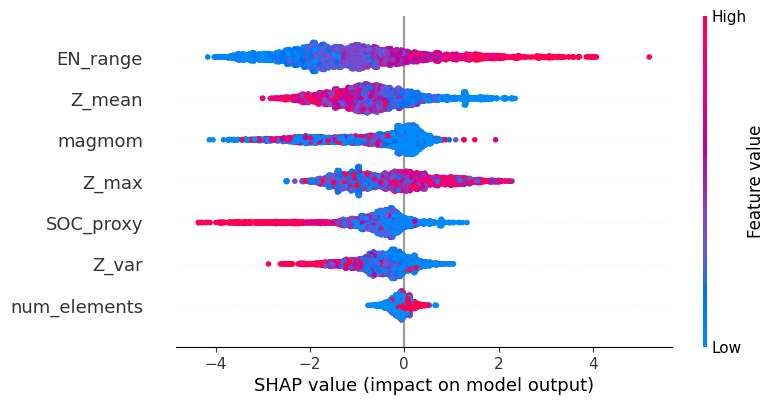

In [13]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

In [14]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

In [15]:
import numpy as np
import pandas as pd

shap_importance = np.abs(shap_values.values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": shap_importance
}).sort_values(by="importance", ascending=False)

print(shap_df)

        feature  importance
4      EN_range    1.470653
0        Z_mean    0.920954
6        magmom    0.794719
1         Z_max    0.781562
3     SOC_proxy    0.751792
2         Z_var    0.564281
5  num_elements    0.154280


In [16]:
shap_df.to_csv("shap_importance.csv", index=False)

In [17]:
import matplotlib.pyplot as plt

plt.figure()
shap.plots.beeswarm(shap_values, show=False)
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.close()

In [18]:
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.savefig("shap_bar.png", dpi=300, bbox_inches='tight')
plt.close()

In [19]:
from google.colab import files

files.download("shap_importance.csv")
files.download("shap_beeswarm.png")
files.download("shap_bar.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

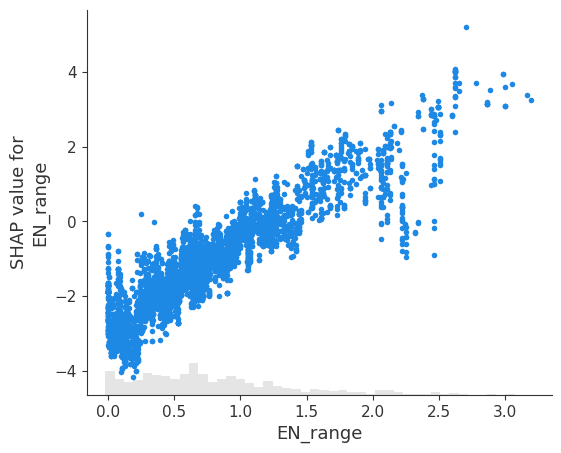

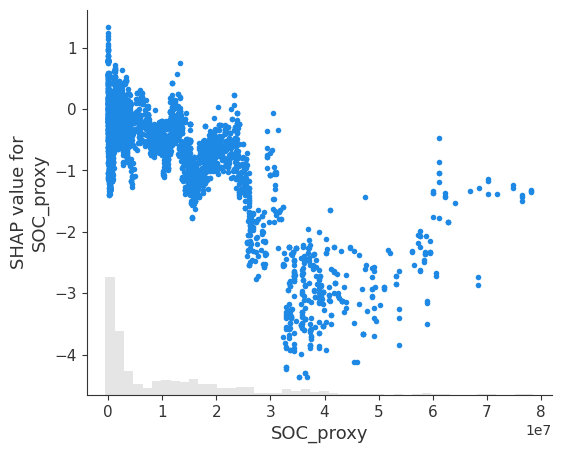

In [20]:
shap.plots.scatter(shap_values[:, "EN_range"])
shap.plots.scatter(shap_values[:, "SOC_proxy"])

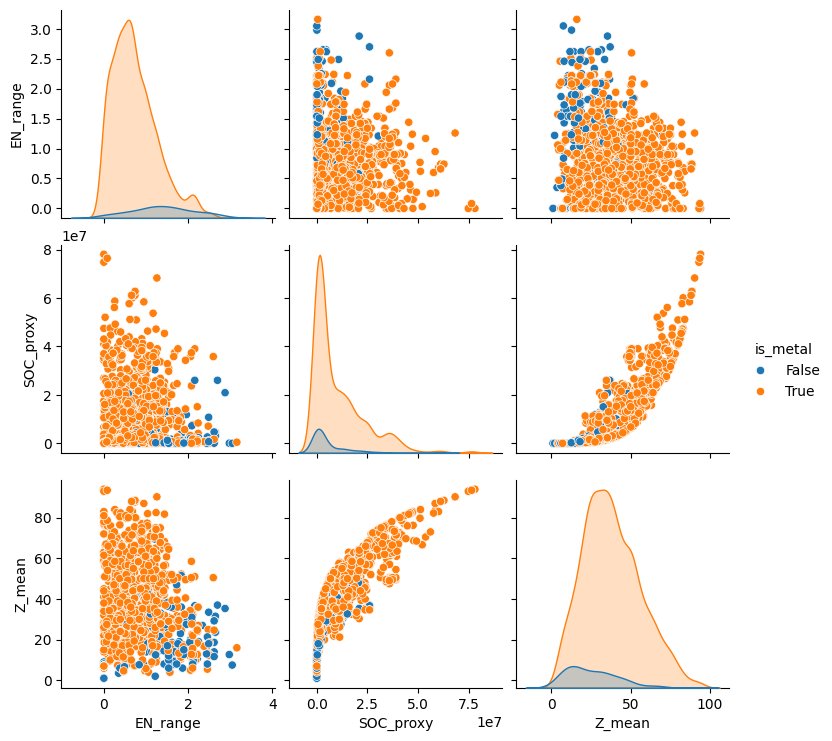

In [21]:
import seaborn as sns

sns.pairplot(df.sample(2000)[[
    "EN_range", "SOC_proxy", "Z_mean", "is_metal"
]], hue="is_metal")

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.close()

In [23]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.close()

In [24]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(7,5))
shap.plots.scatter(shap_values[:, "EN_range"], show=False)

plt.title("SHAP Dependence: EN_range")
plt.savefig("shap_dependence_EN_range.png", dpi=300, bbox_inches='tight')
plt.close()

<Figure size 700x500 with 0 Axes>

In [25]:
plt.figure(figsize=(7,5))
shap.plots.scatter(shap_values[:, "SOC_proxy"], show=False)

plt.title("SHAP Dependence: SOC_proxy")
plt.savefig("shap_dependence_SOC_proxy.png", dpi=300, bbox_inches='tight')
plt.close()

<Figure size 700x500 with 0 Axes>

In [26]:
plt.figure(figsize=(7,5))
shap.plots.scatter(shap_values[:, "magmom"], show=False)

plt.title("SHAP Dependence: Magnetic Moment")
plt.savefig("shap_dependence_magmom.png", dpi=300, bbox_inches='tight')
plt.close()

<Figure size 700x500 with 0 Axes>

In [27]:
plt.figure(figsize=(7,5))
shap.plots.scatter(shap_values[:, "Z_mean"], show=False)

plt.title("SHAP Dependence: Z_mean")
plt.savefig("shap_dependence_Z_mean.png", dpi=300, bbox_inches='tight')
plt.close()

<Figure size 700x500 with 0 Axes>

<Axes: xlabel='EN_range', ylabel='SHAP value for\nEN_range'>

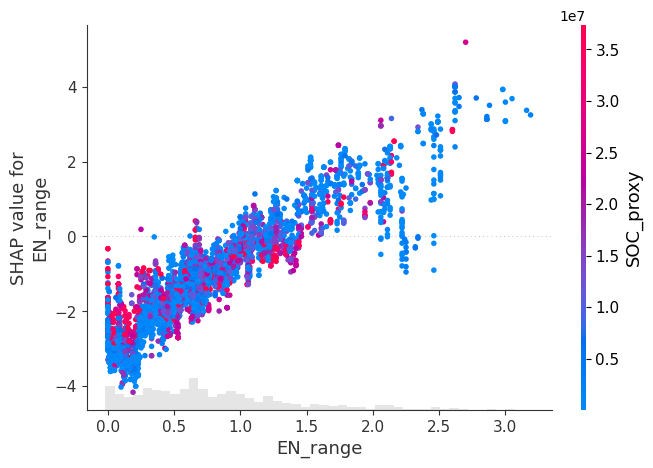

In [28]:
shap.plots.scatter(
    shap_values[:, "EN_range"],
    color=shap_values[:, "SOC_proxy"],
    show=False
)

In [29]:
plt.title("EN_range vs SHAP (colored by SOC)")
plt.savefig("shap_EN_SOC_interaction.png", dpi=300, bbox_inches='tight')
plt.close()

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# ==============================
# 📁 Create output directory
# ==============================
out_dir = "ml_results"
os.makedirs(out_dir, exist_ok=True)

# ==============================
# 🧠 SHAP computation
# ==============================
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# ==============================
# 📊 SHAP importance (NUMBERS)
# ==============================
shap_importance = np.abs(shap_values.values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": shap_importance
}).sort_values(by="importance", ascending=False)

shap_df.to_csv(f"{out_dir}/shap_importance.csv", index=False)

# ==============================
# 🖼️ SHAP BEESWARM
# ==============================
plt.figure(figsize=(8,6))
shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP Beeswarm")
plt.savefig(f"{out_dir}/shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.close()

# ==============================
# 🖼️ SHAP BAR
# ==============================
plt.figure(figsize=(8,6))
shap.plots.bar(shap_values, show=False)
plt.title("SHAP Feature Importance")
plt.savefig(f"{out_dir}/shap_bar.png", dpi=300, bbox_inches='tight')
plt.close()

# ==============================
# 📈 DEPENDENCE PLOTS
# ==============================
features_to_plot = ["EN_range", "SOC_proxy", "magmom", "Z_mean"]

for feat in features_to_plot:
    if feat in X_test.columns:
        plt.figure(figsize=(7,5))
        shap.plots.scatter(shap_values[:, feat], show=False)
        plt.title(f"SHAP Dependence: {feat}")
        plt.savefig(f"{out_dir}/shap_dependence_{feat}.png", dpi=300, bbox_inches='tight')
        plt.close()

# ==============================
# 🎨 INTERACTION PLOT (important)
# ==============================
if "EN_range" in X_test.columns and "SOC_proxy" in X_test.columns:
    plt.figure(figsize=(7,5))
    shap.plots.scatter(
        shap_values[:, "EN_range"],
        color=shap_values[:, "SOC_proxy"],
        show=False
    )
    plt.title("EN_range vs SHAP (colored by SOC)")
    plt.savefig(f"{out_dir}/shap_EN_SOC_interaction.png", dpi=300, bbox_inches='tight')
    plt.close()

# ==============================
# 📊 CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.savefig(f"{out_dir}/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.close()

# ==============================
# 📈 ROC CURVE
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(f"{out_dir}/roc_curve.png", dpi=300, bbox_inches='tight')
plt.close()

print(f"\n✅ All results saved in folder: {out_dir}")


✅ All results saved in folder: ml_results


<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

In [32]:
from google.colab import files
import shutil

shutil.make_archive("ml_results", 'zip', "ml_results")
files.download("ml_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
def classify_phase(gap):
    if gap < 0.05:
        return "metal"
    elif gap < 0.5:
        return "semimetal"
    else:
        return "insulator"

df["phase"] = df["band_gap"].apply(classify_phase)

In [34]:
print(df["phase"].value_counts(normalize=True))

phase
metal        0.908555
insulator    0.059147
semimetal    0.032298
Name: proportion, dtype: float64


In [35]:
df["is_semimetal"] = (df["phase"] == "semimetal").astype(int)

In [36]:
print(df["is_semimetal"].value_counts(normalize=True))

is_semimetal
0    0.967702
1    0.032298
Name: proportion, dtype: float64


In [37]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["phase", "is_semimetal", "material_id"])
y = df["is_semimetal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [38]:
import numpy as np

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 29.947775628626694


In [39]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:19:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [40]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [41]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3872
           1       1.00      1.00      1.00       129

    accuracy                           1.00      4001
   macro avg       1.00      1.00      1.00      4001
weighted avg       1.00      1.00      1.00      4001

ROC-AUC: 1.0


In [44]:
print(X.columns)

Index(['space_group', 'Z_mean', 'Z_max', 'Z_var', 'SOC_proxy', 'EN_range',
       'num_elements', 'magmom', 'is_magnetic'],
      dtype='object')


In [43]:
X = df.drop(columns=[
    "phase",
    "is_semimetal",
    "material_id",
    "band_gap",        # 🚨 leakage
    "energy",          # ⚠️ remove
    "cohesive_energy", # ⚠️ remove
    "is_metal"         # 🚨 derived from band_gap
])

In [45]:
print(X.columns)

Index(['space_group', 'Z_mean', 'Z_max', 'Z_var', 'SOC_proxy', 'EN_range',
       'num_elements', 'magmom', 'is_magnetic'],
      dtype='object')


In [46]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [48]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3872
           1       1.00      1.00      1.00       129

    accuracy                           1.00      4001
   macro avg       1.00      1.00      1.00      4001
weighted avg       1.00      1.00      1.00      4001

ROC-AUC: 1.0


In [49]:
def classify_phase_strict(gap):
    if gap < 0.01:
        return "metal"
    elif gap < 0.1:
        return "semimetal"
    else:
        return "insulator"

df["phase_strict"] = df["band_gap"].apply(classify_phase_strict)

In [50]:
df["is_semimetal"] = (df["phase_strict"] == "semimetal").astype(int)

In [51]:
print(df["is_semimetal"].value_counts(normalize=True))

is_semimetal
0    0.9919
1    0.0081
Name: proportion, dtype: float64


In [52]:
X = df.drop(columns=[
    "phase",
    "phase_strict",
    "is_semimetal",
    "material_id",
    "band_gap",
    "energy",
    "cohesive_energy",
    "is_metal"
])

In [53]:
y = df["is_semimetal"]

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [55]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

122.07692307692308


In [56]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [57]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3969
           1       0.04      0.22      0.07        32

    accuracy                           0.96      4001
   macro avg       0.52      0.59      0.53      4001
weighted avg       0.99      0.96      0.97      4001

ROC-AUC: 0.6511676429831192


In [58]:
def symmetry_features(sg):
    # inversion symmetry (rough heuristic)
    centrosymmetric_sgs = set([
        2, 10, 11, 12, 13, 14, 15, 47, 48, 49, 50, 51, 52,
        53, 54, 55, 56, 57, 58, 59, 60, 61, 62,
        123, 124, 125, 126, 127, 128, 129, 130,
        131, 132, 133, 134, 135, 136, 137, 138,
        139, 140, 141, 142, 143, 144, 145, 146
    ])

    return {
        "has_inversion": int(sg in centrosymmetric_sgs),
        "is_high_symmetry": int(sg > 140),  # cubic / high symmetry
    }

sym_df = df["space_group"].apply(lambda x: symmetry_features(x))
sym_df = pd.DataFrame(list(sym_df))

df = pd.concat([df, sym_df], axis=1)

In [59]:
print(df[["space_group", "has_inversion", "is_high_symmetry"]].head())

   space_group  has_inversion  is_high_symmetry
0            1              0                 0
1            1              0                 0
2            8              0                 0
3            1              0                 0
4            1              0                 0


In [60]:
X = df.drop(columns=[
    "phase",
    "phase_strict",
    "is_semimetal",
    "material_id",
    "band_gap",
    "energy",
    "cohesive_energy",
    "is_metal"
])

In [61]:
y = df["is_semimetal"]

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [63]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

122.07692307692308


In [64]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [65]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3969
           1       0.04      0.22      0.07        32

    accuracy                           0.96      4001
   macro avg       0.52      0.59      0.52      4001
weighted avg       0.99      0.96      0.97      4001

ROC-AUC: 0.654513888888889


In [66]:
df["topology_score"] = (
    df["SOC_proxy"] * df["Z_mean"] / (df["EN_range"] + 1e-3)
)

In [67]:
df[["SOC_proxy", "Z_mean", "EN_range", "topology_score"]].head()

,SOC_proxy,Z_mean,EN_range,topology_score
0,406200.5,18.5,1.39,5.402379e+06
1,1273848.5,30.5,0.32,1.210354e+08
2,1273848.5,30.5,0.32,1.210354e+08
3,1273848.5,30.5,0.32,1.210354e+08
4,1273848.5,30.5,0.32,1.210354e+08


In [68]:
X = df.drop(columns=[
    "phase",
    "phase_strict",
    "is_semimetal",
    "material_id",
    "band_gap",
    "energy",
    "cohesive_energy",
    "is_metal"
])

In [69]:
y = df["is_semimetal"]

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [71]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

122.07692307692308


In [72]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [73]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3969
           1       0.04      0.22      0.07        32

    accuracy                           0.96      4001
   macro avg       0.52      0.59      0.53      4001
weighted avg       0.99      0.96      0.97      4001

ROC-AUC: 0.6379480032753844
